# N-Queens via SAT — experiments

Encoding and benchmarking are in `nqueens.py` and `bench.py`respectively, this notebook only runs them and generates the results. 

In [1]:
# pick up edits to nqueens.py and bench.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import platform
import sys

import pysat

print(sys.version)
print(platform.platform())
print(platform.processor())
print("python-sat", pysat.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Windows-10-10.0.26200-SP0
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
python-sat 1.9.dev7


## 1. Check on a small board

First-run for n=8 to check the encoding and everyhting else is correct.

In [2]:
from pysat.solvers import Solver

from bench import SOLVERS, max_n_within, run_one, sweep, to_records
from nqueens import decode, encode, render, verify

n = 8
enc = encode(n)

with Solver(name="cadical153", bootstrap_with=enc.clauses) as s:
    sat = s.solve()
    model = s.get_model()

pos = decode(model, n)

print(f"n={n}  vars={enc.n_vars}  clauses={enc.n_clauses}")
print(f"sat={sat}  verified={verify(pos, n)}")
print(f"positions={pos}")
print()
print(render(pos, n))

n=8  vars=64  clauses=512
sat=True  verified=True
positions=[5, 3, 6, 0, 2, 4, 1, 7]

. . . . . Q . .
. . . Q . . . .
. . . . . . Q .
Q . . . . . . .
. . Q . . . . .
. . . . Q . . .
. Q . . . . . .
. . . . . . . Q


## 2. Known-value check

Set up for n=2 and n=3 must come out UNSAT, every other n SAT.

In [3]:
EXPECTED_UNSAT = {2, 3}

print(f"{'n':>3} {'sat':>6} {'expected':>9} {'verified':>9}")
for n in range(1, 11):
    enc = encode(n)
    with Solver(name="cadical153", bootstrap_with=enc.clauses) as s:
        sat = s.solve()
        model = s.get_model() if sat else None

    expected = n not in EXPECTED_UNSAT
    ok = verify(decode(model, n), n) if sat else "-"
    flag = "" if sat == expected else "MISMATCH"
    print(f"{n:>3} {str(sat):>6} {str(expected):>9} {str(ok):>9}{flag}")

  n    sat  expected  verified
  1   True      True      True
  2  False     False         -
  3  False     False         -
  4   True      True      True
  5   True      True      True
  6   True      True      True
  7   True      True      True
  8   True      True      True
  9   True      True      True
 10   True      True      True


## 3. Encoding size

Variable and clause counts as a function of n (should be fast).

In [4]:
import pandas as pd

from nqueens import clause_count

# counted from the literal groups, so nothing large is built in this kernel
sizes = [
    {
        "n": n,
        "vars": n * n,
        "clauses": clause_count(n),
        "clauses / n^3": round(clause_count(n) / n**3, 3),
    }
    for n in [8, 16, 32, 64, 100, 150, 200, 250, 300, 350]
]

df_size = pd.DataFrame(sizes)
df_size

,n,vars,clauses,clauses / n^3
0,8,64,512,1.000
1,16,256,4416,1.078
2,32,1024,36736,1.121
3,64,4096,299776,1.144
4,100,10000,1151800,1.152
5,150,22500,3903950,1.157
6,200,40000,9273600,1.159
7,250,62500,18135750,1.161
8,300,90000,31365400,1.162
9,350,122500,49837550,1.162


## 4. Comparison of performance time, time with respect to n, across three solvers 

Encoding and solving time are recorded separately so Python-side encoding cost does not mix up with the solver comparison.

In [5]:
NS = [8, 16, 32, 64, 100, 150, 200, 250, 300, 350]
BUDGET = 60.0

results = sweep(NS, SOLVERS, budget=BUDGET)

df = pd.DataFrame(to_records(results))
df.to_csv("results.csv", index=False)
df

  n=   8 cadical153   encode=  0.001s load=  0.001s solve=  0.000s verified=True
  n=   8 glucose4     encode=  0.001s load=  0.008s solve=  0.002s verified=True
  n=   8 minisat22    encode=  0.003s load=  0.000s solve=  0.001s verified=True
  n=  16 cadical153   encode=  0.002s load=  0.004s solve=  0.060s verified=True
  n=  16 glucose4     encode=  0.003s load=  0.003s solve=  0.005s verified=True
  n=  16 minisat22    encode=  0.002s load=  0.002s solve=  0.002s verified=True
  n=  32 cadical153   encode=  0.009s load=  0.018s solve=  0.376s verified=True
  n=  32 glucose4     encode=  0.007s load=  0.015s solve=  9.918s verified=True
  n=  32 minisat22    encode=  0.009s load=  0.016s solve=  0.004s verified=True
  n=  64 cadical153   encode=  0.108s load=  0.138s solve=  0.911s verified=True
  n=  64 glucose4     encode=  0.089s load=  0.137s solve=  0.013s verified=True
  n=  64 minisat22    encode=  0.118s load=  0.128s solve=  0.016s verified=True
  n= 100 cadical153   encode

,n,solver,sat,encode_time,load_time,solve_time,n_vars,n_clauses,verified,timed_out,error,restarts,conflicts,decisions,propagations,solver_time,total_time
0,8,cadical153,True,0.000945,0.001059,0.000165,64,512,True,False,None,0.0,15.0,25.0,341.0,0.001224,0.002169
1,8,glucose4,True,0.000787,0.008063,0.001704,64,512,True,False,None,1.0,289.0,403.0,3541.0,0.009766,0.010553
2,8,minisat22,True,0.003130,0.000379,0.000530,64,512,True,False,None,2.0,117.0,205.0,1938.0,0.000909,0.004039
3,16,cadical153,True,0.001637,0.003826,0.060002,256,4416,True,False,None,78.0,3857.0,5126.0,129513.0,0.063828,0.065464
4,16,glucose4,True,0.002553,0.002714,0.004965,256,4416,True,False,None,2.0,490.0,1067.0,9654.0,0.007679,0.010232
5,16,minisat22,True,0.002197,0.002220,0.001728,256,4416,True,False,None,3.0,206.0,640.0,6541.0,0.003948,0.006145
6,32,cadical153,True,0.008741,0.017527,0.376378,1024,36736,True,False,None,303.0,10020.0,13879.0,793327.0,0.393904,0.402646
7,32,glucose4,True,0.007392,0.015131,9.917640,1024,36736,True,False,None,3.0,100025.0,121448.0,2448651.0,9.932771,9.940163
8,32,minisat22,True,0.009281,0.016347,0.004386,1024,36736,True,False,None,3.0,221.0,2014.0,13758.0,0.020733,0.030014
9,64,cadical153,True,0.108406,0.137940,0.910661,4096,299776,True,False,None,257.0,10020.0,16804.0,2088977.0,1.048602,1.157008


## 5. Largest n solved within one minute

The headline result the task asks for, per solver.

In [6]:
metrics = {
    "search only": "solve",
    "search + clause loading": "solver",
    "everything incl. encoding": "total",
}

print(f"largest n within {BUDGET:.0f}s\n")
print(f"{'solver':<12}" + "".join(f"{k:>28}" for k in metrics))
for name in SOLVERS:
    row = "".join(
        f"{max_n_within(results, BUDGET, metric=m).get(name, 0):>28}"
        for m in metrics.values()
    )
    print(f"{name:<12}{row}")

print()
print(f"{'solver':<12} {'n':>5} {'encode':>9} {'load':>9} {'solve':>9} {'total':>9}")
for name in SOLVERS:
    sub = df[(df.solver == name) & df.solve_time.notna()]
    if len(sub):
        r = sub.loc[sub.n.idxmax()]
        print(
            f"{name:<12} {int(r.n):>5} {r.encode_time:>9.3f} {r.load_time:>9.3f} "
            f"{r.solve_time:>9.3f} {r.total_time:>9.3f}"
        )

largest n within 60s

solver                       search only     search + clause loading   everything incl. encoding
cadical153                           250                         250                         250
glucose4                              64                          64                          64
minisat22                            300                         300                         300

solver           n    encode      load     solve     total
cadical153     250     8.578     8.384    34.658    51.620
glucose4        64     0.089     0.137     0.013     0.238
minisat22      300    15.109    22.936     0.928    38.973


## 6. Plots for the report

Export figures to `../report/figures/` so the LaTeX source can include them directly.

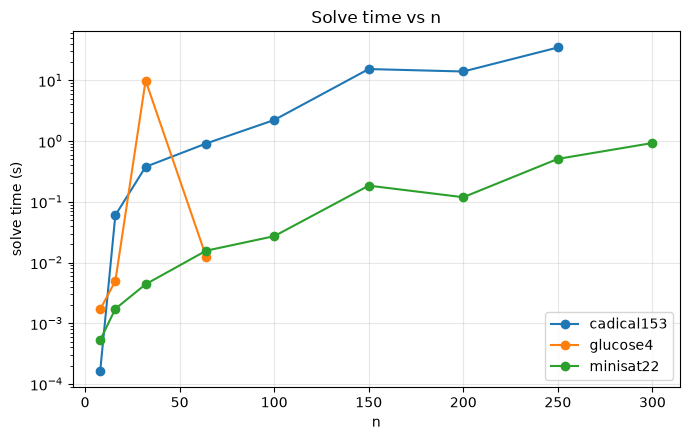

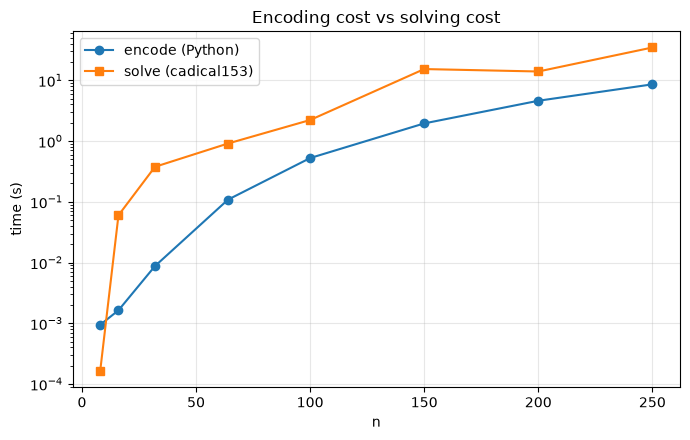

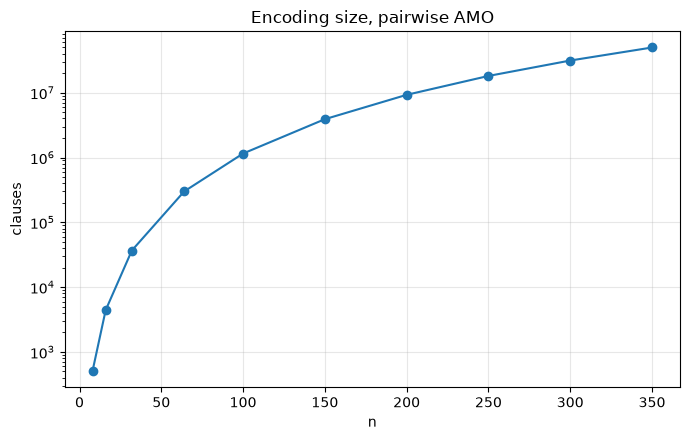

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt

figdir = Path("../report/figures")
figdir.mkdir(parents=True, exist_ok=True)

ok = df[~df.timed_out & df.error.isna()]

fig, ax = plt.subplots(figsize=(7, 4.5))
for name in SOLVERS:
    sub = ok[ok.solver == name].sort_values("n")
    ax.plot(sub.n, sub.solve_time, marker="o", label=name)
ax.set_xlabel("n")
ax.set_ylabel("solve time (s)")
ax.set_yscale("log")
ax.set_title("Solve time vs n")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "solve_time.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
sub = ok[ok.solver == "cadical153"].sort_values("n")
ax.plot(sub.n, sub.encode_time, marker="o", label="encode (Python)")
ax.plot(sub.n, sub.solve_time, marker="s", label="solve (cadical153)")
ax.set_xlabel("n")
ax.set_ylabel("time (s)")
ax.set_yscale("log")
ax.set_title("Encoding cost vs solving cost")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "encode_vs_solve.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_size.n, df_size.clauses, marker="o")
ax.set_xlabel("n")
ax.set_ylabel("clauses")
ax.set_yscale("log")
ax.set_title("Encoding size, pairwise AMO")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(figdir / "clause_count.pdf")
plt.show()

## 7. Solver statistics

Restarts, conflicts, decisions and propagations reported by each solver. These are independent of the machine, so they compare the solvers without any timing noise.

In [8]:
stats_cols = ["restarts", "conflicts", "decisions", "propagations"]

df_stats = (
    df[df.solve_time.notna()][["n", "solver", "solve_time"] + stats_cols]
    .sort_values(["n", "solver"])
    .reset_index(drop=True)
)
df_stats.to_csv("stats.csv", index=False)
df_stats

,n,solver,solve_time,restarts,conflicts,decisions,propagations
0,8,cadical153,0.000165,0.0,15.0,25.0,341.0
1,8,glucose4,0.001704,1.0,289.0,403.0,3541.0
2,8,minisat22,0.000530,2.0,117.0,205.0,1938.0
3,16,cadical153,0.060002,78.0,3857.0,5126.0,129513.0
4,16,glucose4,0.004965,2.0,490.0,1067.0,9654.0
5,16,minisat22,0.001728,3.0,206.0,640.0,6541.0
6,32,cadical153,0.376378,303.0,10020.0,13879.0,793327.0
7,32,glucose4,9.917640,3.0,100025.0,121448.0,2448651.0
8,32,minisat22,0.004386,3.0,221.0,2014.0,13758.0
9,64,cadical153,0.910661,257.0,10020.0,16804.0,2088977.0


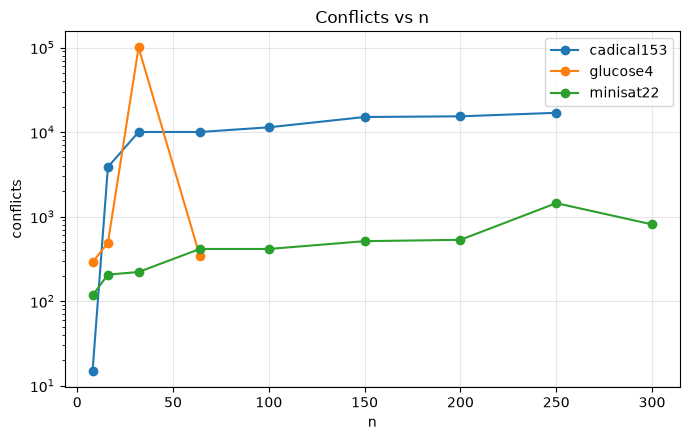

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in SOLVERS:
    sub = df_stats[df_stats.solver == name].sort_values("n")
    ax.plot(sub.n, sub.conflicts, marker="o", label=name)
ax.set_xlabel("n")
ax.set_ylabel("conflicts")
ax.set_yscale("log")
ax.set_title("Conflicts vs n")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "conflicts.pdf")
plt.show()

## 8. Non-monotonicity

Cases where a larger board was solved faster than a smaller one. Solving time does not grow steadily with n, which is why a single measurement such as the largest n within a minute should be read with care.

In [10]:
from bench import non_monotone

drops = non_monotone(results)

if drops:
    print(f"{'solver':<12} {'n':>5} {'time':>9}  ->  {'n':>5} {'time':>9} {'speedup':>9}")
    for d in drops:
        print(
            f"{d['solver']:<12} {d['n_small']:>5} {d['t_small']:>9.3f}  ->  "
            f"{d['n_large']:>5} {d['t_large']:>9.3f} {d['speedup']:>8.1f}x"
        )
else:
    print("no non-monotone pairs in this run")

pd.DataFrame(drops)

solver           n      time  ->      n      time   speedup
glucose4        32     9.918  ->     64     0.013    790.8x
minisat22      150     0.184  ->    200     0.119      1.6x
cadical153     150    15.307  ->    200    13.956      1.1x


,solver,n_small,t_small,n_large,t_large,speedup
0,glucose4,32,9.917640,64,0.012541,790.823662
1,minisat22,150,0.184368,200,0.118863,1.551100
2,cadical153,150,15.306834,200,13.956246,1.096773
